Dataset shape: (4240, 16)
Column 'education' removed. New shape: (4240, 15)

EXPLORATORY DATA ANALYSIS

--- Basic Info ---
male                 int64
age                  int64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

--- Statistical Summary ---
          male      age  currentSmoker  cigsPerDay   BPMeds  prevalentStroke  \
count  4240.00  4240.00        4240.00     4211.00  4187.00          4240.00   
mean      0.43    49.58           0.49        9.01     0.03             0.01   
std       0.50     8.57           0.50       11.92     0.17             0.08   
min       0.00    32.00           0.00        0.00     0.00             0.00   
25%       0.00    42.00      

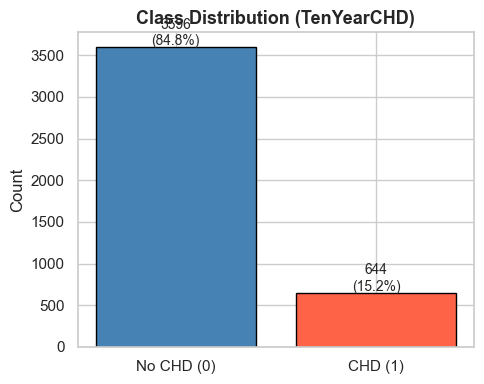

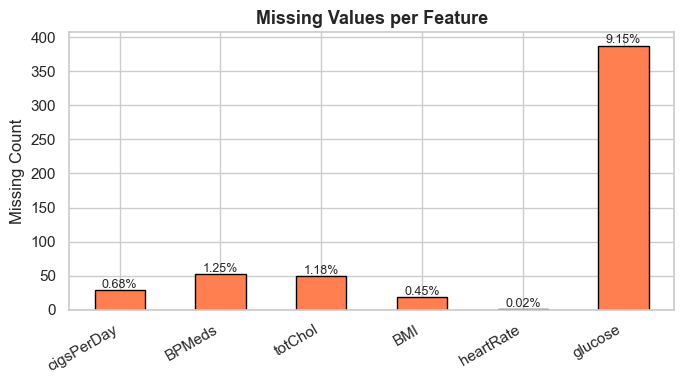

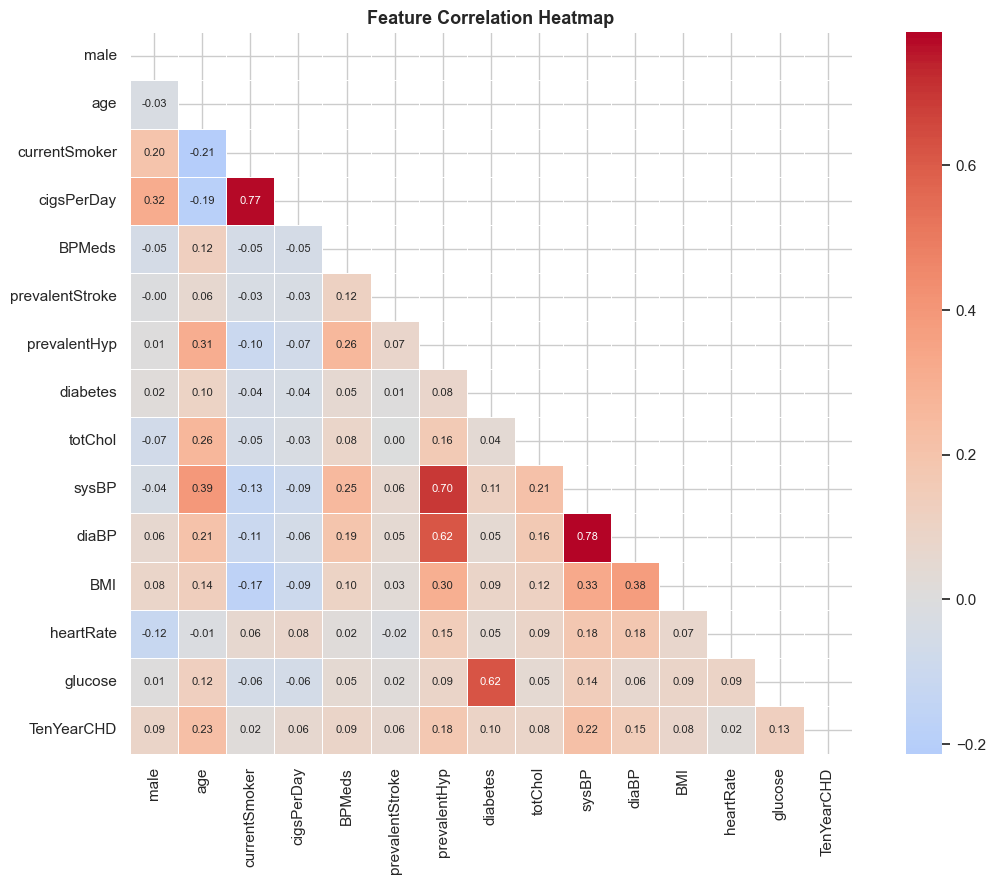

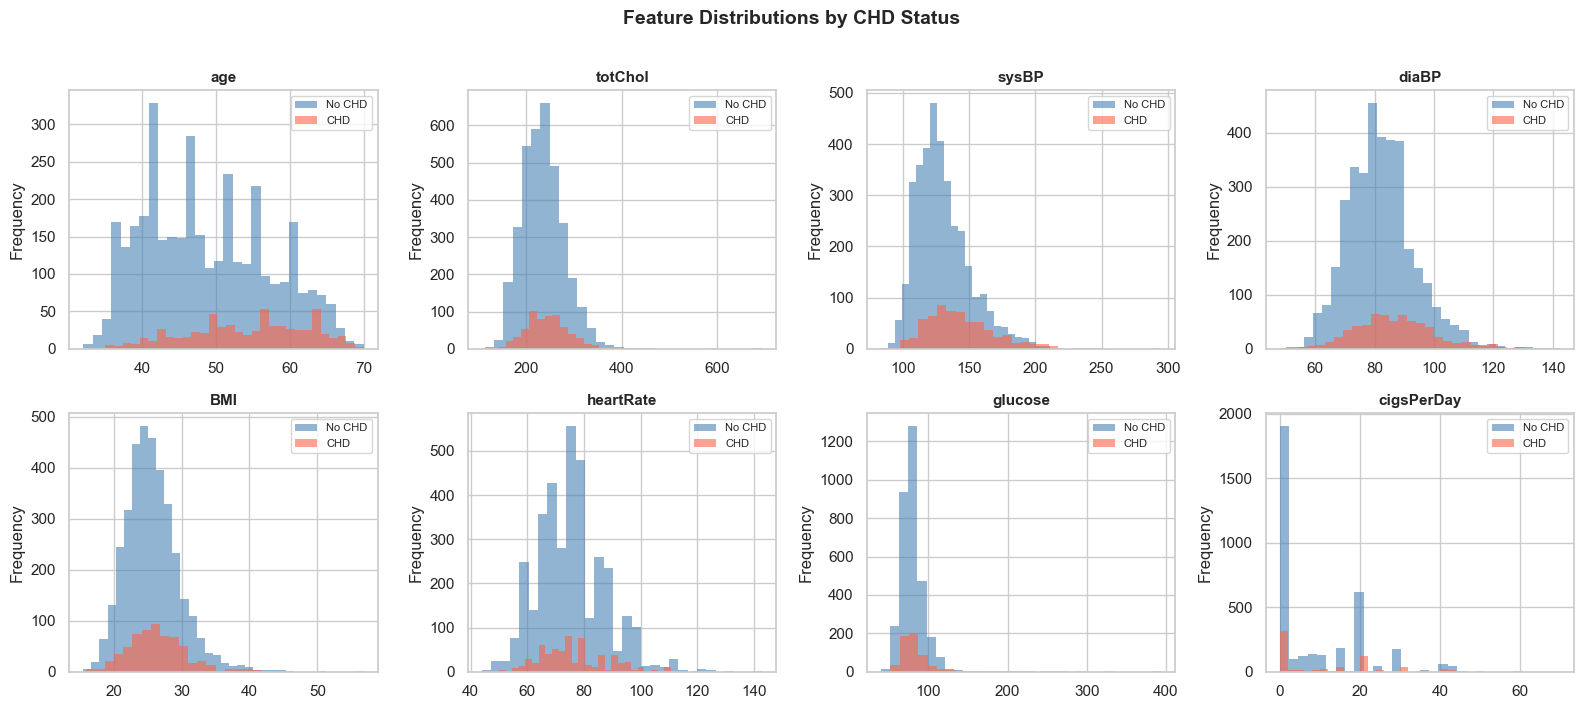

C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=["No CHD", "CHD"],
C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=["No CHD", "CHD"],
C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=["No CHD", "CHD"],
C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:146: MatplotlibD

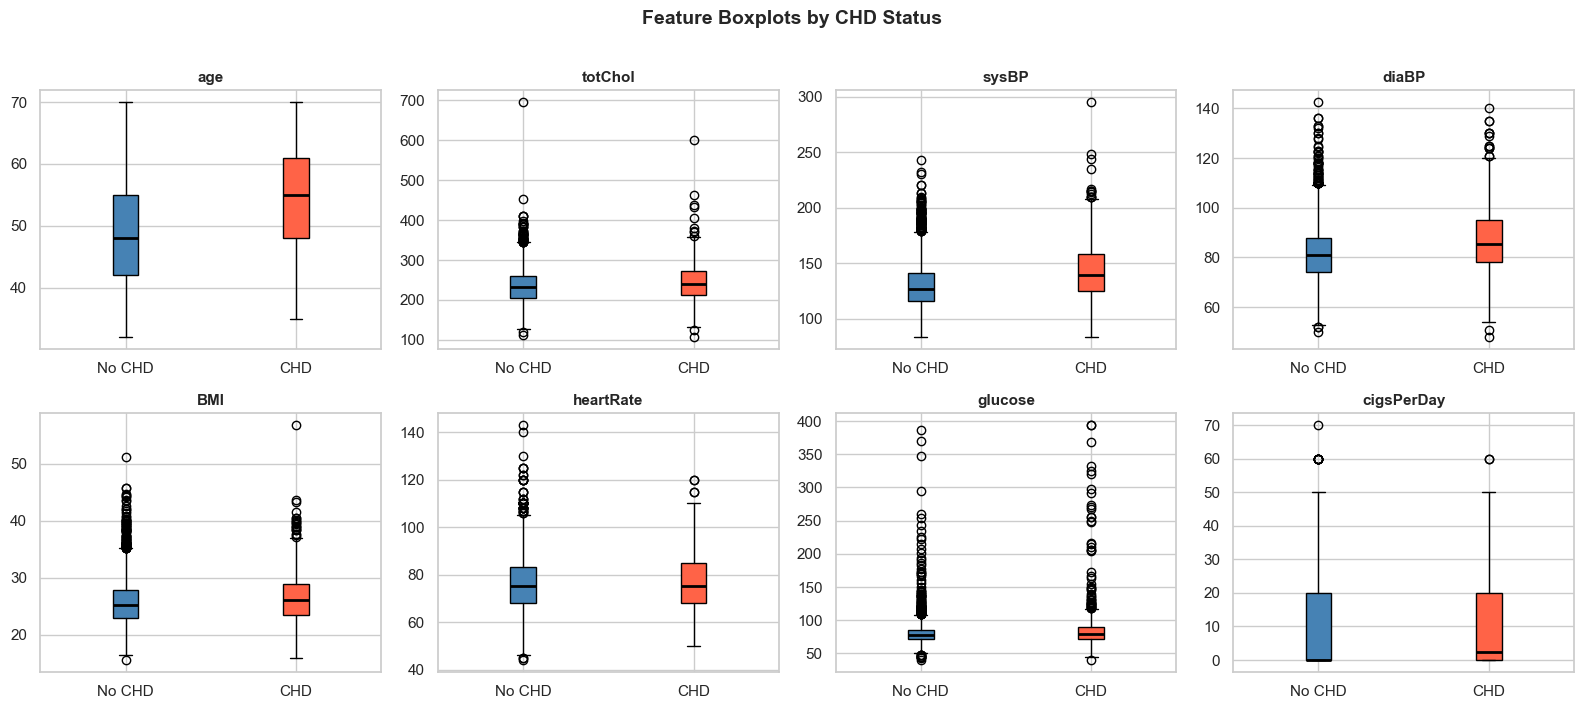

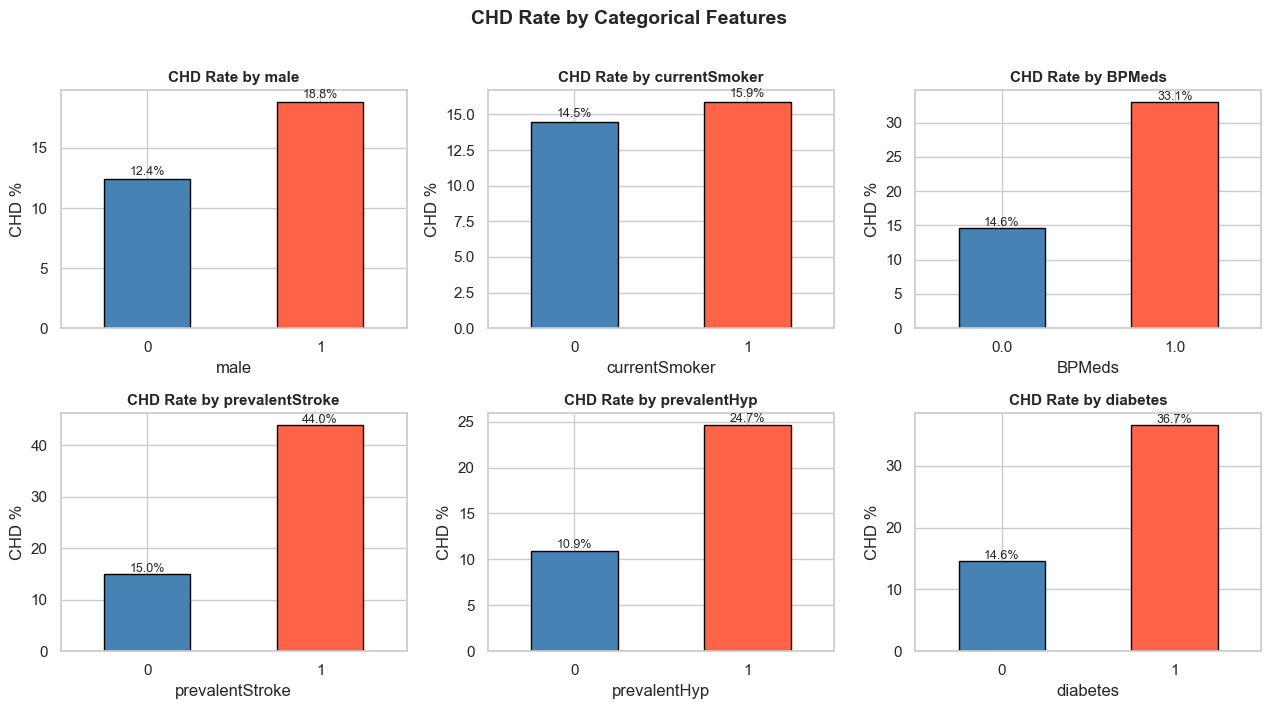


EDA complete. Plots saved.

MISSING VALUE HANDLING
No CHD rows dropped (had missing): 417
No CHD rows remaining: 3179
CHD rows (median-imputed, none dropped): 644

Cleaned dataset shape: (3823, 15)
Remaining missing values: 0

Class distribution after cleaning:
No CHD (0): 3179  (83.15%)
CHD    (1): 644  (16.85%)

Split sizes:
Train: (2293, 16)   Validation: (765, 16)   Test: (765, 16)


C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:197: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_chd[col].fillna(med, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_35564\962330039.py:197: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin


Best LR params: {'model__C': 0.005, 'model__penalty': 'l1'}
Best XGB params: {'model__subsample': 0.7, 'model__n_estimators': 150, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.9}

Chosen model : Logistic Regression
LR  val recall : 0.6744  (threshold 0.515)
XGB val recall : 0.6124  (threshold 0.485)

TRAIN
-----
Threshold      : 0.515
Accuracy       : 0.6485
Balanced Acc   : 0.6451
ROC-AUC        : 0.7070
Precision      : 0.2702
Recall         : 0.6399
F1             : 0.3800

Classification Report:
              precision    recall  f1-score   support

           0     0.8992    0.6502    0.7547      1907
           1     0.2702    0.6399    0.3800       386

    accuracy                         0.6485      2293
   macro avg     0.5847    0.6451    0.5674      2293
weighted avg     0.7933    0.6485    0.6916      2293


VALIDATION
----------
Threshold      : 0.515
Accuracy       : 0.6614
Balanced Ac

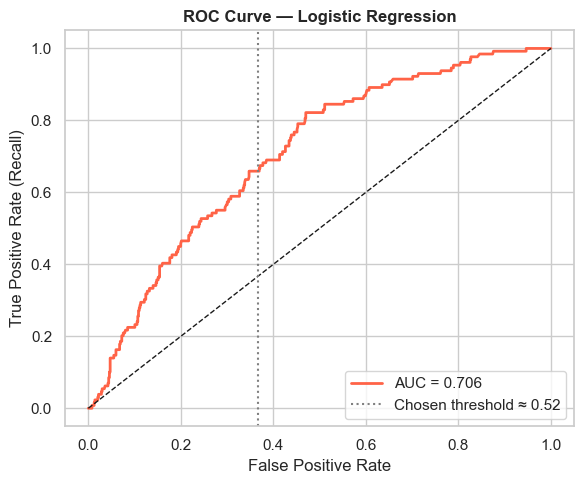

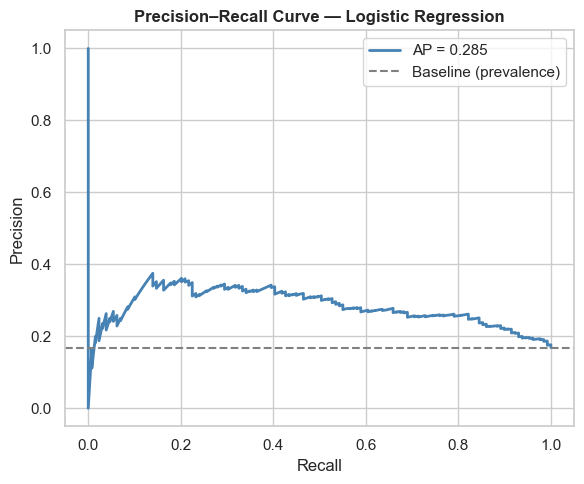

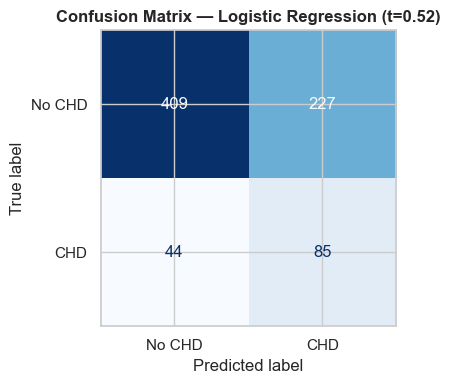

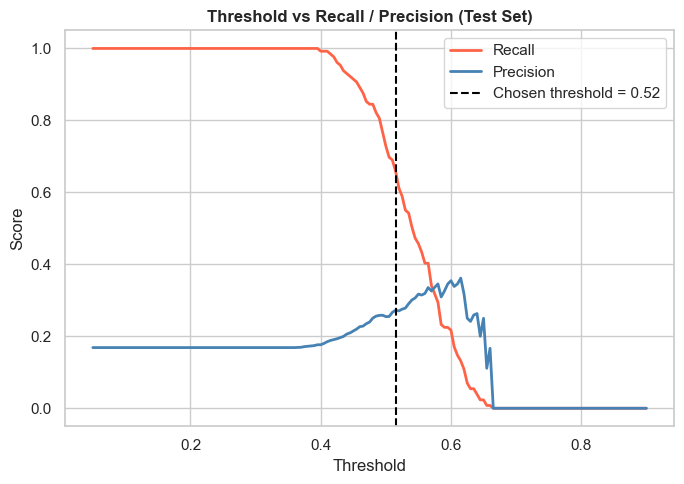


Done.


In [4]:
from app import ten_year_model, ten_year_threshold
# =========================================================
# HEART DISEASE PREDICTION (without 'education')
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("framingham.csv")
print("Dataset shape:", df.shape)

# --- Drop 'education' column ---
df.drop('education', axis=1, inplace=True)
print("Column 'education' removed. New shape:", df.shape)

# =========================================================
# 2. EDA
# =========================================================
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# --- 2.1 Basic summary ---
print("\n--- Basic Info ---")
print(df.dtypes)
print("\n--- Statistical Summary ---")
print(df.describe().round(2))

# --- 2.2 Class distribution ---
print("\n--- Target Class Distribution ---")
class_counts = df["TenYearCHD"].value_counts()
class_pct    = df["TenYearCHD"].value_counts(normalize=True) * 100
print(f"No CHD (0): {class_counts[0]}  ({class_pct[0]:.2f}%)")
print(f"CHD    (1): {class_counts[1]}  ({class_pct[1]:.2f}%)")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")

# --- 2.3 Missing values ---
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percentage": missing_pct})
print(missing_df)

# --- 2.4 Missing by class ---
print("\n--- Missing Rows by Class ---")
has_missing = df.isnull().any(axis=1)
for label, name in [(0, "No CHD"), (1, "CHD")]:
    mask = df["TenYearCHD"] == label
    n = (has_missing & mask).sum()
    pct = n / mask.sum() * 100
    print(f"{name}: {n} rows with missing ({pct:.2f}% of {name} rows)")

# ---- EDA PLOTS ----
sns.set_theme(style="whitegrid", palette="muted")

# Plot 1: Class distribution bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No CHD (0)", "CHD (1)"], [class_counts[0], class_counts[1]],
       color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Class Distribution (TenYearCHD)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax.text(i, v + 30, f"{v}\n({[class_pct[0], class_pct[1]][i]:.1f}%)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
plt.show()

# Plot 2: Missing value bar chart
fig, ax = plt.subplots(figsize=(7, 4))
missing_df["Count"].plot(kind="bar", ax=ax, color="coral", edgecolor="black")
ax.set_title("Missing Values per Feature", fontsize=13, fontweight="bold")
ax.set_ylabel("Missing Count")
ax.set_xticklabels(missing_df.index, rotation=30, ha="right")
for i, (count, pct) in enumerate(zip(missing_df["Count"], missing_df["Percentage"])):
    ax.text(i, count + 3, f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_missing_values.png", dpi=150)
plt.show()

# Plot 3: Correlation heatmap (without 'education')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()

# Plot 4: Feature distributions by class
features_to_plot = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "cigsPerDay"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    for label, color, name in [(0, "steelblue", "No CHD"), (1, "tomato", "CHD")]:
        subset = df[df["TenYearCHD"] == label][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor="none")
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Frequency")
plt.suptitle("Feature Distributions by CHD Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_feature_distributions.png", dpi=150)
plt.show()

# Plot 5: Boxplots by class for key continuous features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    data = [df[df["TenYearCHD"] == 0][feat].dropna(),
            df[df["TenYearCHD"] == 1][feat].dropna()]
    bp = axes[i].boxplot(data, patch_artist=True, labels=["No CHD", "CHD"],
                         medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
plt.suptitle("Feature Boxplots by CHD Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150)
plt.show()

# Plot 6: Categorical feature rates
cat_features = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i, feat in enumerate(cat_features):
    chd_rate = df.groupby(feat)["TenYearCHD"].mean() * 100
    chd_rate.plot(kind="bar", ax=axes[i], color=["steelblue", "tomato"], edgecolor="black")
    axes[i].set_title(f"CHD Rate by {feat}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("CHD %")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    for j, v in enumerate(chd_rate):
        axes[i].text(j, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
plt.suptitle("CHD Rate by Categorical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_categorical_chd_rates.png", dpi=150)
plt.show()

print("\nEDA complete. Plots saved.")

# =========================================================
# 3. MISSING VALUE HANDLING (BEFORE SPLIT)
# =========================================================
print("\n" + "="*60)
print("MISSING VALUE HANDLING")
print("="*60)

# Split by class BEFORE any imputation
df_no_chd = df[df["TenYearCHD"] == 0].copy()   # class 0
df_chd    = df[df["TenYearCHD"] == 1].copy()   # class 1

# No CHD: drop any row that has at least one missing value
rows_before = len(df_no_chd)
df_no_chd = df_no_chd.dropna()
rows_after = len(df_no_chd)
print(f"No CHD rows dropped (had missing): {rows_before - rows_after}")
print(f"No CHD rows remaining: {rows_after}")

# CHD: fill missing with median (computed within CHD subset only)
for col in df_chd.columns:
    if df_chd[col].isnull().any():
        med = df_chd[col].median()
        df_chd[col].fillna(med, inplace=True)
print(f"CHD rows (median-imputed, none dropped): {len(df_chd)}")

# Recombine
df_clean = pd.concat([df_no_chd, df_chd], ignore_index=True)
print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

# Verify class distribution after cleaning
cc = df_clean["TenYearCHD"].value_counts()
print(f"\nClass distribution after cleaning:")
print(f"No CHD (0): {cc[0]}  ({cc[0]/len(df_clean)*100:.2f}%)")
print(f"CHD    (1): {cc[1]}  ({cc[1]/len(df_clean)*100:.2f}%)")

# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================
df_clean["pulsePressure"] = df_clean["sysBP"] - df_clean["diaBP"]
df_clean["bp_ratio"]      = df_clean["sysBP"] / (df_clean["diaBP"] + 1e-6)

# =========================================================
# 5. FEATURES / TARGET  (education removed)
# =========================================================
features = [
    "age", "male", "currentSmoker", "cigsPerDay",
    "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes",
    "totChol", "sysBP", "diaBP", "pulsePressure", "bp_ratio",
    "BMI", "heartRate", "glucose"
]

X = df_clean[features].copy()
y = df_clean["TenYearCHD"].copy()

# =========================================================
# 6. SPLIT
# =========================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

print("\nSplit sizes:")
print("Train:", X_train.shape, "  Validation:", X_val.shape, "  Test:", X_test.shape)

# =========================================================
# 7. THRESHOLD SELECTION  (recall-first strategy)
# =========================================================
def select_threshold(y_true, y_proba, min_recall=0.60, precision_weight=0.35):
    thresholds = np.linspace(0.05, 0.90, 171)

    best     = {"threshold": 0.50, "score": -1}
    fallback = best.copy()

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)

        score = precision_weight * prec + (1 - precision_weight) * acc

        if score > fallback["score"]:
            fallback = {"threshold": t, "score": score}

        if rec >= min_recall and score > best["score"]:
            best = {"threshold": t, "score": score}

    return best if best["score"] >= 0 else fallback


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    acc  = accuracy_score(y_eval, y_pred)
    bacc = balanced_accuracy_score(y_eval, y_pred)
    auc  = roc_auc_score(y_eval, y_proba)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec  = recall_score(y_eval, y_pred, zero_division=0)
    f1   = f1_score(y_eval, y_pred, zero_division=0)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Threshold      : {threshold:.3f}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Balanced Acc   : {bacc:.4f}")
    print(f"ROC-AUC        : {auc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1             : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, digits=4))

    return {
        "accuracy": acc, "balanced_accuracy": bacc,
        "roc_auc": auc, "precision": prec, "recall": rec,
    }

# =========================================================
# 8. LOGISTIC REGRESSION
# =========================================================
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

lr_grid = {
    "model__C":       [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0],
    "model__penalty": ["l1", "l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="recall", cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print("\nBest LR params:", lr_search.best_params_)

lr_val_proba = best_lr.predict_proba(X_val)[:, 1]
lr_thresh    = select_threshold(y_val, lr_val_proba)

# =========================================================
# 9. XGBOOST
# =========================================================
neg, pos        = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

xgb_param_dist = {
    "model__n_estimators":    [100, 150, 200, 300],
    "model__max_depth":       [2, 3, 4],
    "model__learning_rate":   [0.01, 0.03, 0.05],
    "model__subsample":       [0.70, 0.80, 0.90],
    "model__colsample_bytree":[0.70, 0.80, 0.90],
    "model__min_child_weight":[3, 5, 7],
    "model__gamma":           [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=30,
    scoring="recall", cv=cv, n_jobs=-1, random_state=RANDOM_STATE
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)

xgb_val_proba = best_xgb.predict_proba(X_val)[:, 1]
xgb_thresh    = select_threshold(y_val, xgb_val_proba)

# =========================================================
# 10. MODEL SELECTION
# =========================================================
lr_val_recall  = recall_score(y_val, (lr_val_proba  >= lr_thresh["threshold"]).astype(int))
xgb_val_recall = recall_score(y_val, (xgb_val_proba >= xgb_thresh["threshold"]).astype(int))

if xgb_val_recall >= lr_val_recall:
    chosen_model     = best_xgb
    chosen_threshold = xgb_thresh["threshold"]
    chosen_name      = "XGBoost"
else:
    chosen_model     = best_lr
    chosen_threshold = lr_thresh["threshold"]
    chosen_name      = "Logistic Regression"

print(f"\nChosen model : {chosen_name}")
print(f"LR  val recall : {lr_val_recall:.4f}  (threshold {lr_thresh['threshold']:.3f})")
print(f"XGB val recall : {xgb_val_recall:.4f}  (threshold {xgb_thresh['threshold']:.3f})")

# =========================================================
# 11. EVALUATIONS (TRAIN / VAL / TEST)
# =========================================================
train_res = evaluate_model("TRAIN",      chosen_model, X_train, y_train, chosen_threshold)
val_res   = evaluate_model("VALIDATION", chosen_model, X_val,   y_val,   chosen_threshold)
test_res  = evaluate_model("TEST",       chosen_model, X_test,  y_test,  chosen_threshold)

# =========================================================
# 12. GENERALIZATION CHECK
# =========================================================
print("\n" + "="*60)
print("GENERALIZATION CHECK")
print("="*60)

auc_gap = train_res["roc_auc"] - test_res["roc_auc"]
acc_gap = train_res["accuracy"] - test_res["accuracy"]
rec_gap = train_res["recall"]   - test_res["recall"]

print(f"AUC Gap      (Train - Test): {auc_gap:.4f}")
print(f"Accuracy Gap (Train - Test): {acc_gap:.4f}")
print(f"Recall Gap   (Train - Test): {rec_gap:.4f}")

if auc_gap > 0.07 or acc_gap > 0.07:
    print("⚠  Overfitting detected")
elif train_res["roc_auc"] < 0.62 and test_res["roc_auc"] < 0.62:
    print("⚠  Underfitting detected")
else:
    print("✔  Model is well-generalised")

# =========================================================
# 13. POST-TRAINING PLOTS
# =========================================================

# ROC Curve
proba = chosen_model.predict_proba(X_test)[:, 1]
fpr, tpr, roc_thresholds = roc_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="tomato", lw=2,
        label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.axvline(x=fpr[np.argmin(np.abs(roc_thresholds - chosen_threshold))],
           color="gray", linestyle=":", label=f"Chosen threshold ≈ {chosen_threshold:.2f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title(f"ROC Curve — {chosen_name}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

# Precision–Recall Curve
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_curve, prec_curve, color="steelblue", lw=2, label=f"AP = {ap:.3f}")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", label="Baseline (prevalence)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision–Recall Curve — {chosen_name}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150)
plt.show()

# Confusion Matrix
y_pred_test = (proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No CHD", "CHD"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {chosen_name} (t={chosen_threshold:.2f})",
             fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Threshold vs Recall / Precision trade-off
thresholds_range = np.linspace(0.05, 0.90, 171)
recalls_range, precisions_range = [], []
for t in thresholds_range:
    yp = (proba >= t).astype(int)
    recalls_range.append(recall_score(y_test, yp, zero_division=0))
    precisions_range.append(precision_score(y_test, yp, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds_range, recalls_range,    label="Recall",    color="tomato",    lw=2)
ax.plot(thresholds_range, precisions_range, label="Precision", color="steelblue", lw=2)
ax.axvline(chosen_threshold, color="black", linestyle="--",
           label=f"Chosen threshold = {chosen_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold vs Recall / Precision (Test Set)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tradeoff.png", dpi=150)
plt.show()

print("\nDone.")

import pickle
from pathlib import Path

Path("ten_year_models").mkdir(exist_ok=True)

with open("ten_year_models/ten_year_model.pkl", "wb") as f:
    pickle.dump(ten_year_model, f)

with open("ten_year_models/ten_year_threshold.pkl", "wb") as f:
    pickle.dump(ten_year_threshold, f)